# Chapter 5 - Merge HLL++ Hash Mismatch

Notebook per analizzare la matrice minima di `hash mismatch` su `HyperLogLog++`.

Obiettivi:
- caricare tutti i CSV `results_merge_heterogeneous.csv` della campagna minima;
- separare controlli omogenei, `reject` e `unsafe_naive_merge`;
- quantificare la degradazione del merge forzato rispetto al riferimento seriale omogeneo;
- salvare una sintesi numerica e due figure compatte in `thesis/figures/results`.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Repository root non trovata')


REPO = find_repo_root(Path.cwd().resolve())
RESULTS_ROOT = REPO / 'results'
OUT_DIR = REPO / 'thesis' / 'figures' / 'results'
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_GLOB = 'merge_hpp_hash_mismatch_min*/**/results_merge_heterogeneous.csv'

HASH_ORDER = ['splitmix64', 'xxhash64', 'murmurhash3', 'siphash24']
SCENARIO_ORDER = ['ctrl', 'seed_xx', 'seed_xx_rev', 'seed_murmur', 'seed_murmur_rev', 'family', 'family_rev']
SCENARIO_LABELS = {
    'ctrl': 'homogeneous direct',
    'seed_xx': 'seed mismatch xxhash64',
    'seed_xx_rev': 'seed mismatch xxhash64 (rev)',
    'seed_murmur': 'seed mismatch murmurhash3',
    'seed_murmur_rev': 'seed mismatch murmurhash3 (rev)',
    'family': 'family mismatch xxhash64 -> other',
    'family_rev': 'family mismatch other -> xxhash64',
}

print('REPO:', REPO)
print('RESULTS_ROOT:', RESULTS_ROOT)
print('OUT_DIR:', OUT_DIR)
print('RESULTS_GLOB:', RESULTS_GLOB)


REPO: /home/daniele/Dev/satp-cpp
RESULTS_ROOT: /home/daniele/Dev/satp-cpp/results
OUT_DIR: /home/daniele/Dev/satp-cpp/thesis/figures/results
RESULTS_GLOB: merge_hpp_hash_mismatch_min*/**/results_merge_heterogeneous.csv


In [2]:
def parse_meta(path: Path) -> dict:
    rel = path.relative_to(RESULTS_ROOT)
    namespace = rel.parts[0]
    cfg = rel.parts[3]
    params = rel.parts[4]

    m_ns = re.match(r'merge_hpp_hash_mismatch_min_(.+?)_d_(\d+)$', namespace)
    if not m_ns:
        raise ValueError(f'Namespace non riconosciuto: {namespace}')
    scenario, d_raw = m_ns.groups()

    m_cfg = re.match(r'left_(.+?)_seed_(\d+)_right_(.+?)_seed_(\d+)$', cfg)
    if not m_cfg:
        raise ValueError(f'Configurazione hash non riconosciuta: {cfg}')
    left_hash, left_seed, right_hash, right_seed = m_cfg.groups()

    m_params = re.match(r'left_k_(\d+)_right_k_(\d+)_strategy_(.+)$', params)
    if not m_params:
        raise ValueError(f'Parametri non riconosciuti: {params}')
    left_k, right_k, strategy = m_params.groups()

    d = int(d_raw)
    rho = int(round(10_000_000 / d))
    return {
        'namespace': namespace,
        'scenario': scenario,
        'd': d,
        'rho': rho,
        'left_hash': left_hash,
        'right_hash': right_hash,
        'left_hash_seed': int(left_seed),
        'right_hash_seed': int(right_seed),
        'left_k': int(left_k),
        'right_k': int(right_k),
        'strategy': strategy,
    }


frames = []
for csv_path in sorted(RESULTS_ROOT.glob(RESULTS_GLOB)):
    meta = parse_meta(csv_path)
    frame = pd.read_csv(csv_path)
    for key, value in meta.items():
        frame[key] = value
    frames.append(frame)

if not frames:
    raise RuntimeError('Nessun CSV trovato per la campagna hash mismatch')

df = pd.concat(frames, ignore_index=True)
df['scenario'] = pd.Categorical(df['scenario'], categories=SCENARIO_ORDER, ordered=True)
df['degradation_ratio'] = df['error_merge_rel_exact'] / df['error_serial_rel_exact']
df['baseline_gap_rel'] = (df['estimate_merge'] - df['baseline_homogeneous']).abs() / df['exact_union']

print('files:', len(frames))
print('rows:', len(df))
print('scenarios:', sorted(df['scenario'].dropna().unique().tolist()))
print('strategies:', sorted(df['strategy'].unique().tolist()))
print('validities:', sorted(df['validity'].unique().tolist()))
print('d values:', sorted(df['d'].unique().tolist()))
print('rho values:', sorted(df['rho'].unique().tolist()))

display(df.head())


files: 72
rows: 1800
scenarios: ['ctrl', 'family', 'family_rev', 'seed_murmur', 'seed_murmur_rev', 'seed_xx', 'seed_xx_rev']
strategies: ['direct', 'reject', 'unsafe_naive_merge']
validities: ['invalid', 'valid']
d values: [100000, 1000000, 10000000]
rho values: [1, 10, 100]


,algorithm,mode,pairs,sample_size,pair_index,dataset_seed,left_hash,right_hash,left_hash_seed,right_hash_seed,...,baseline_homogeneous,delta_vs_baseline,namespace,scenario,d,rho,left_k,right_k,degradation_ratio,baseline_gap_rel
0,HyperLogLog++,merge_heterogeneous,25,10000000,0,21041998,murmurhash3,murmurhash3,21041998,21041998,...,197692,0.0,merge_hpp_hash_mismatch_min_ctrl_d_100000,ctrl,100000,100,14,14,1.0,0.0
1,HyperLogLog++,merge_heterogeneous,25,10000000,1,21041998,murmurhash3,murmurhash3,21041998,21041998,...,197496,0.0,merge_hpp_hash_mismatch_min_ctrl_d_100000,ctrl,100000,100,14,14,1.0,0.0
2,HyperLogLog++,merge_heterogeneous,25,10000000,2,21041998,murmurhash3,murmurhash3,21041998,21041998,...,197176,0.0,merge_hpp_hash_mismatch_min_ctrl_d_100000,ctrl,100000,100,14,14,1.0,0.0
3,HyperLogLog++,merge_heterogeneous,25,10000000,3,21041998,murmurhash3,murmurhash3,21041998,21041998,...,197681,0.0,merge_hpp_hash_mismatch_min_ctrl_d_100000,ctrl,100000,100,14,14,1.0,0.0
4,HyperLogLog++,merge_heterogeneous,25,10000000,4,21041998,murmurhash3,murmurhash3,21041998,21041998,...,197868,0.0,merge_hpp_hash_mismatch_min_ctrl_d_100000,ctrl,100000,100,14,14,1.0,0.0


In [3]:
summary_runs = (
    df.groupby(['scenario', 'strategy', 'validity', 'd', 'rho', 'left_hash', 'right_hash'], dropna=False)
      .agg(
          pairs=('pair_index', 'size'),
          merge_rel_mean=('error_merge_rel_exact', 'mean'),
          merge_rel_median=('error_merge_rel_exact', 'median'),
          merge_rel_max=('error_merge_rel_exact', 'max'),
          serial_rel_mean=('error_serial_rel_exact', 'mean'),
          baseline_gap_abs_mean=('delta_vs_baseline', 'mean'),
          baseline_gap_abs_max=('delta_vs_baseline', 'max'),
          baseline_gap_rel_mean=('baseline_gap_rel', 'mean'),
          degradation_ratio_mean=('degradation_ratio', 'mean'),
      )
      .reset_index()
      .sort_values(['scenario', 'strategy', 'd', 'left_hash', 'right_hash'])
)

summary_global = (
    df.groupby(['scenario', 'strategy', 'validity'], dropna=False)
      .agg(
          pairs=('pair_index', 'size'),
          merge_rel_mean=('error_merge_rel_exact', 'mean'),
          merge_rel_median=('error_merge_rel_exact', 'median'),
          merge_rel_max=('error_merge_rel_exact', 'max'),
          serial_rel_mean=('error_serial_rel_exact', 'mean'),
          baseline_gap_abs_mean=('delta_vs_baseline', 'mean'),
          baseline_gap_abs_max=('delta_vs_baseline', 'max'),
          degradation_ratio_mean=('degradation_ratio', 'mean'),
      )
      .reset_index()
      .sort_values(['scenario', 'strategy'])
)

summary_ctrl = summary_runs[summary_runs['scenario'] == 'ctrl'][['d', 'rho', 'left_hash', 'merge_rel_mean', 'serial_rel_mean', 'baseline_gap_abs_mean']]
summary_unsafe = summary_runs[summary_runs['strategy'] == 'unsafe_naive_merge'][['scenario', 'd', 'rho', 'left_hash', 'right_hash', 'merge_rel_mean', 'serial_rel_mean', 'baseline_gap_abs_mean', 'baseline_gap_rel_mean', 'degradation_ratio_mean']]

summary_global.to_csv(RESULTS_ROOT / 'merge_hpp_hash_mismatch_summary_global.csv', index=False)
summary_runs.to_csv(RESULTS_ROOT / 'merge_hpp_hash_mismatch_summary_runs.csv', index=False)
summary_ctrl.to_csv(RESULTS_ROOT / 'merge_hpp_hash_mismatch_ctrl_summary.csv', index=False)
summary_unsafe.to_csv(RESULTS_ROOT / 'merge_hpp_hash_mismatch_unsafe_summary.csv', index=False)

display(summary_global)
display(summary_unsafe.head(12))


,scenario,strategy,validity,pairs,merge_rel_mean,merge_rel_median,merge_rel_max,serial_rel_mean,baseline_gap_abs_mean,baseline_gap_abs_max,degradation_ratio_mean
0,ctrl,direct,valid,300,0.006233,0.005637,0.025913,0.006233,0.000000e+00,0.0,1.000000
1,seed_xx,reject,invalid,75,NaN,NaN,NaN,0.007436,NaN,NaN,NaN
2,seed_xx,unsafe_naive_merge,invalid,75,0.342374,0.049889,0.969548,0.007436,3.225919e+06,9585276.0,49.450414
3,seed_xx_rev,reject,invalid,75,NaN,NaN,NaN,0.010076,NaN,NaN,NaN
4,seed_xx_rev,unsafe_naive_merge,invalid,75,0.343830,0.051555,0.969548,0.010076,3.329398e+06,9882996.0,28.817028
5,seed_murmur,reject,invalid,75,NaN,NaN,NaN,0.004836,NaN,NaN,NaN
6,seed_murmur,unsafe_naive_merge,invalid,75,0.347522,0.053738,0.984223,0.004836,3.321858e+06,9867728.0,206.460766
7,seed_murmur_rev,reject,invalid,75,NaN,NaN,NaN,0.004606,NaN,NaN,NaN
8,seed_murmur_rev,unsafe_naive_merge,invalid,75,0.348319,0.054408,0.984223,0.004606,3.311315e+06,9830350.0,307.175413
9,family,reject,invalid,225,NaN,NaN,NaN,0.007436,NaN,NaN,NaN


,scenario,d,rho,left_hash,right_hash,merge_rel_mean,serial_rel_mean,baseline_gap_abs_mean,baseline_gap_rel_mean,degradation_ratio_mean
15,seed_xx,100000,100,xxhash64,xxhash64,0.007634,0.005394,1251.48,0.006289,2.534195
16,seed_xx,1000000,10,xxhash64,xxhash64,0.049942,0.005895,91230.60,0.048017,57.835532
17,seed_xx,10000000,1,xxhash64,xxhash64,0.969548,0.011020,9585276.00,0.958528,87.981515
21,seed_xx_rev,100000,100,xxhash64,xxhash64,0.010628,0.005939,1798.44,0.009037,2.841624
22,seed_xx_rev,1000000,10,xxhash64,xxhash64,0.051314,0.005537,103398.80,0.054422,31.906051
23,seed_xx_rev,10000000,1,xxhash64,xxhash64,0.969548,0.018752,9882996.00,0.988300,51.703409
27,seed_murmur,100000,100,murmurhash3,murmurhash3,0.005696,0.006630,1877.40,0.009434,2.167408
28,seed_murmur,1000000,10,murmurhash3,murmurhash3,0.052648,0.005329,95969.28,0.050511,231.275515
29,seed_murmur,10000000,1,murmurhash3,murmurhash3,0.984223,0.002550,9867728.00,0.986773,385.939377
33,seed_murmur_rev,100000,100,murmurhash3,murmurhash3,0.008029,0.007039,1740.08,0.008744,2.993903


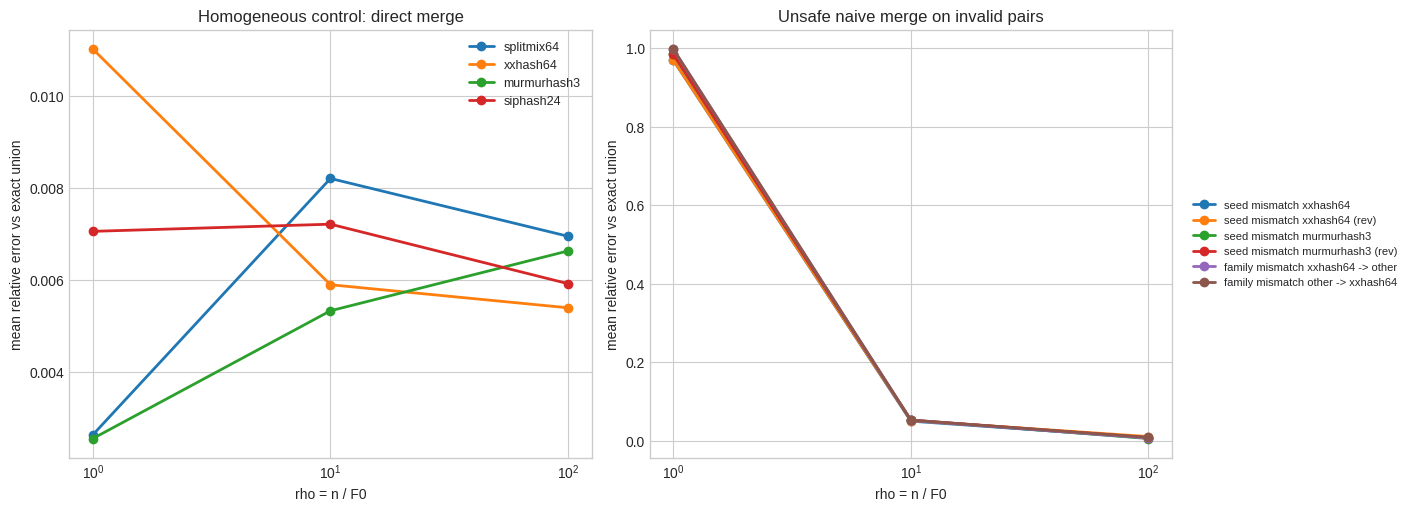

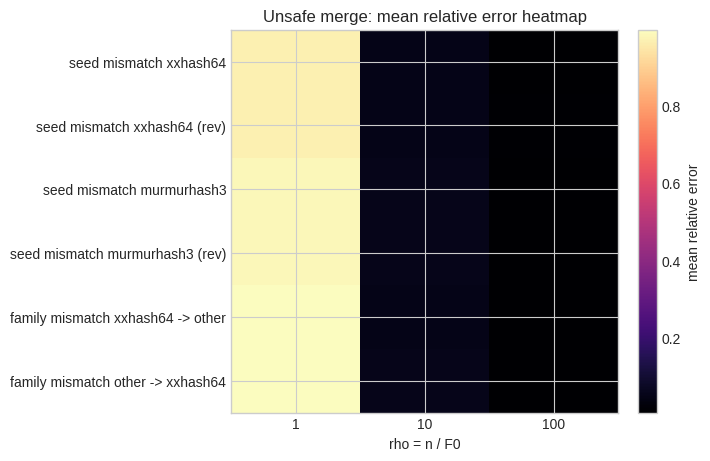

Saved: /home/daniele/Dev/satp-cpp/thesis/figures/results/merge_hpp_hash_mismatch_overview.png
Saved: /home/daniele/Dev/satp-cpp/thesis/figures/results/merge_hpp_hash_mismatch_unsafe_heatmap.png


In [4]:
ctrl_plot = summary_ctrl.copy()
ctrl_plot['left_hash'] = pd.Categorical(ctrl_plot['left_hash'], categories=HASH_ORDER, ordered=True)
ctrl_plot = ctrl_plot.sort_values(['left_hash', 'rho'])

unsafe_plot = summary_unsafe.copy()
unsafe_plot['scenario_label'] = unsafe_plot['scenario'].map(SCENARIO_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for hash_name in HASH_ORDER:
    sub = ctrl_plot[ctrl_plot['left_hash'] == hash_name]
    if sub.empty:
        continue
    axes[0].plot(sub['rho'], sub['merge_rel_mean'], marker='o', linewidth=2, label=hash_name)

axes[0].set_xscale('log')
axes[0].set_xlabel('rho = n / F0')
axes[0].set_ylabel('mean relative error vs exact union')
axes[0].set_title('Homogeneous control: direct merge')
axes[0].legend(loc='best', fontsize=9)

unsafe_grouped = (
    unsafe_plot.groupby(['scenario_label', 'rho'], as_index=False)
               .agg(merge_rel_mean=('merge_rel_mean', 'mean'))
)
for scenario_label in [SCENARIO_LABELS[s] for s in SCENARIO_ORDER if s not in {'ctrl'}]:
    sub = unsafe_grouped[unsafe_grouped['scenario_label'] == scenario_label]
    if sub.empty:
        continue
    axes[1].plot(sub['rho'], sub['merge_rel_mean'], marker='o', linewidth=2, label=scenario_label)

axes[1].set_xscale('log')
axes[1].set_xlabel('rho = n / F0')
axes[1].set_ylabel('mean relative error vs exact union')
axes[1].set_title('Unsafe naive merge on invalid pairs')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

fig.savefig(OUT_DIR / 'merge_hpp_hash_mismatch_overview.png', dpi=200, bbox_inches='tight')
plt.show()

pivot = (
    unsafe_plot.groupby(['scenario', 'rho'], as_index=False)
               .agg(merge_rel_mean=('merge_rel_mean', 'mean'))
               .pivot(index='scenario', columns='rho', values='merge_rel_mean')
               .reindex([s for s in SCENARIO_ORDER if s != 'ctrl'])
)

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
im = ax.imshow(pivot.values, cmap='magma', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(v) for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([SCENARIO_LABELS[s] for s in pivot.index])
ax.set_xlabel('rho = n / F0')
ax.set_title('Unsafe merge: mean relative error heatmap')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('mean relative error')
fig.savefig(OUT_DIR / 'merge_hpp_hash_mismatch_unsafe_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

print('Saved:', OUT_DIR / 'merge_hpp_hash_mismatch_overview.png')
print('Saved:', OUT_DIR / 'merge_hpp_hash_mismatch_unsafe_heatmap.png')


In [5]:
key_findings = pd.DataFrame([
    {
        'finding': 'homogeneous control',
        'value': summary_global.query("scenario == 'ctrl' and strategy == 'direct'")['merge_rel_mean'].iloc[0],
        'note': 'Il merge diretto omogeneo coincide con il seriale e resta nel range atteso di errore HLL++',
    },
    {
        'finding': 'unsafe invalid merge',
        'value': summary_global.query("strategy == 'unsafe_naive_merge'")['merge_rel_mean'].mean(),
        'note': 'Il merge forzato su sketch incompatibili e\' molto peggiore del baseline omogeneo',
    },
    {
        'finding': 'worst-case unsafe invalid merge',
        'value': summary_global.query("strategy == 'unsafe_naive_merge'")['merge_rel_max'].max(),
        'note': 'Quando rho = 1 il merge forzato arriva vicino a errore relativo 1',
    },
])

display(key_findings)


,finding,value,note
0,homogeneous control,0.006233,Il merge diretto omogeneo coincide con il seri...
1,unsafe invalid merge,0.347814,Il merge forzato su sketch incompatibili e' mo...
2,worst-case unsafe invalid merge,1.009634,Quando rho = 1 il merge forzato arriva vicino ...
